In [69]:
import pandas as pd
import numpy as np
import sklearn.datasets as data
from sklearn.model_selection import train_test_split as tts
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import seaborn as sns

In [70]:
d=data.load_diabetes()
df=pd.DataFrame(d.data, columns=d.feature_names)
df['target']=d.target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [71]:
print("\nData Info:\n",df.info())
print("\nData description:\n",df.describe())
print("\nData shape:",df.shape)
print("\nData co-relation:\n",df.corr()['target'].sort_values(ascending=False))


<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB

Data Info:
 None

Data description:
                 age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164

In [72]:
x=df.drop(columns=['target','sex'])
y=df['target']

In [73]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.25,random_state=42)

In [74]:
# Multi-Linear Regression

model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [75]:
y_pred=model.predict(x_test)

In [76]:
print("\nR2 Score: ",r2_score(y_test,y_pred)*100,"%")
print("\nMean Absolute Error: ",mean_absolute_error(y_test,y_pred))
print("\nMean Squared Error: ",mean_squared_error(y_test,y_pred))



R2 Score:  47.05871168973683 %

Mean Absolute Error:  42.85452579437818

Mean Squared Error:  2927.4890185726313


In [77]:
df_importance = pd.DataFrame({'Feature': x.columns,'Coefficient': model.coef_})
print("Feature Importances:\n\n",df_importance.sort_values(by='Coefficient',ascending=False))

Feature Importances:

   Feature  Coefficient
7      s5   725.564444
1     bmi   573.254023
4      s2   501.926495
2      bp   337.479907
6      s4   169.731875
5      s3   139.422041
8      s6    17.610583
0     age    14.367539
3      s1  -866.468818


In [34]:
# Testing
new_patient = [[0.01, 0.05, 0.02, -0.01, -0.03, 0.04, -0.02, 0.01, 0.03]]
new_patient=pd.DataFrame(new_patient,columns=x.columns)
pred=model.predict(new_patient)
print(pred)

[190.76788565]


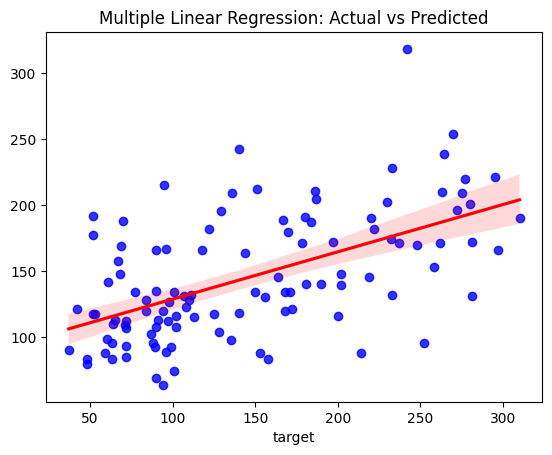

In [67]:
sns.regplot(x=y_test, y=y_pred, scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})

plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.show()

In [112]:
# Now removing s6 and age due to low coefficient values

x=df.drop(columns=['age','s6','s3','s4','target'])
x.head()

,sex,bmi,bp,s1,s2,s5
0,0.050680,0.061696,0.021872,-0.044223,-0.034821,0.019907
1,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,-0.068332
2,0.050680,0.044451,-0.005670,-0.045599,-0.034194,0.002861
3,-0.044642,-0.011595,-0.036656,0.012191,0.024991,0.022688
4,-0.044642,-0.036385,0.021872,0.003935,0.015596,-0.031988


In [113]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.25,random_state=42)

In [114]:
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [115]:
y_pred=model.predict(x_test)

In [116]:
print("\nR2 Score: ",r2_score(y_test,y_pred)*100,"%")
print("\nMean Absolute Error: ",mean_absolute_error(y_test,y_pred))
print("\nMean Squared Error: ",mean_squared_error(y_test,y_pred))



R2 Score:  49.497466049984126 %

Mean Absolute Error:  41.42678710335675

Mean Squared Error:  2792.6334675180487


In [52]:
# Simple Linear Regression

d=data.load_diabetes()
df=pd.DataFrame(d.data, columns=d.feature_names)
df['target']=d.target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [53]:
print("Co-relation w.r.t target variable: \n",df.corr()['target'].abs().sort_values(ascending=False))

Co-relation w.r.t target variable: 
 target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s3        0.394789
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
Name: target, dtype: float64


In [54]:
# Will Select bmi as it has the highest co-relation with the target variable

x=df[['bmi']]
y=df[['target']]
print(x.head(),"\n")
print(y.head(),"\n")

        bmi
0  0.061696
1 -0.051474
2  0.044451
3 -0.011595
4 -0.036385 

   target
0   151.0
1    75.0
2   141.0
3   206.0
4   135.0 



In [55]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.25,random_state=42)

In [56]:
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [57]:
y_pred=model.predict(x_test)
print("These are the predicted values by the model:\n",y_pred)

These are the predicted values by the model:
 [[146.02400874]
 [188.07062105]
 [148.12633936]
 [202.78693536]
 [132.35885974]
 [128.15419851]
 [318.41511922]
 [196.47994352]
 [ 64.03311473]
 [167.0473149 ]
 [119.74487605]
 [ 95.56807397]
 [ 92.41457804]
 [165.99614959]
 [ 97.67040458]
 [157.58682713]
 [221.7079109 ]
 [238.52655583]
 [179.66129859]
 [209.09392721]
 [190.17295167]
 [110.28438828]
 [103.97739643]
 [174.40547205]
 [195.42877821]
 [165.99614959]
 [210.14509252]
 [134.46119036]
 [ 79.80059435]
 [131.30769443]
 [242.73121706]
 [115.54021482]
 [165.99614959]
 [146.02400874]
 [191.22411698]
 [228.01490275]
 [121.84720666]
 [119.74487605]
 [121.84720666]
 [ 95.56807397]
 [ 84.00525558]
 [122.89837197]
 [130.25652913]
 [119.74487605]
 [108.18205766]
 [117.64254543]
 [116.59138012]
 [102.92623112]
 [ 69.28894127]
 [153.3821659 ]
 [209.09392721]
 [ 84.00525558]
 [169.14964551]
 [112.38671889]
 [134.46119036]
 [215.40091906]
 [107.13089235]
 [212.24742313]
 [134.46119036]
 [ 98.7215

In [58]:
print("\nR2 Score: ",r2_score(y_test,y_pred)*100,"%")
print("\nMean Absolute Error: ",mean_absolute_error(y_test,y_pred))
print("\nMean Squared Error: ",mean_squared_error(y_test,y_pred))



R2 Score:  31.720994495377795 %

Mean Absolute Error:  49.80505217504619

Mean Squared Error:  3775.6172015007787


In [65]:
print('Coefficient:', model.coef_)

Coefficient: [[975.27698313]]


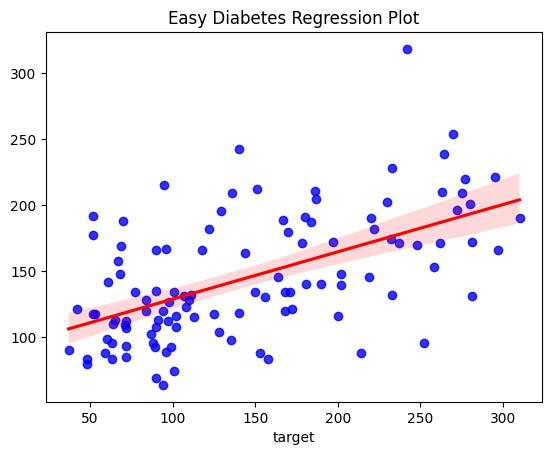

In [59]:
sns.regplot(data=df, x=y_test, y=y_pred, scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})

plt.title("Easy Diabetes Regression Plot")
plt.show()